# <span style="color:rgb(160,0,86)">Regressionsanalyse</span>

***

## <span style="color:rgb(160,0,86)">Lernziele</span>

- Sie können eine **multiple lineare Regression** durchführen.
- Sie verstehen den Unterschied zwischen einer *in-Sample* und einer *out-of-Sample* Validierung und können eine **Kreuzvalidierung** durchführen.  
- Sie können nominale Merkmale mit **Faktorvariablen** in ein Modell einbeziehen.
- Sie können eine **Vorwärtsselektion** durchführen.  

***

### <span style="color:rgb(160,0,86)">Was ist eine multiple lineare Regression?</span>

Bei einer **multiplen linearen Regression** werden mehrere Einflussgrössen (Prädiktoren) in einem linearen Modell gleichzeitig betrachtet:
$$\;\;Y = \texttt{predict}(X_1,X_2,\ldots,X_m) = a_1\cdot X_1 + a_2\cdot X_2 + \ldots + a_m\cdot X_m + b$$

Wieder aus einer Stichprobe werden die **Regressionsparameter** $\pmb{\hat{a}_1}, \pmb{\hat{a}_2}, \ldots, \pmb{\hat{a}_m}, \pmb{\hat{b}}$ geschätzt. Das Vorgehen und die Analyse sind sonst identisch. Einzig beim **Standardfehler der Residuen** wird die ***Anzahl Prädiktoren*** $\pmb{m}$ berücksichtigt: $$\pmb{\mathsf{RSE} = \sqrt{\frac{\mathsf{RSS}}{n-\textcolor{red}{(m+1)}}}=\sqrt{\frac{r_1^2+r_2^2+r_3^2+\ldots+r_n^2}{n-\textcolor{red}{(m+1)}}} }$$  

**Beim Schätzen der** $\pmb{m+1}$ **Parameter** $\,\pmb{a_1},\pmb{a_2},\ldots,\pmb{a_m}\,$ und $\,\pmb{b}\,$ verlieren wir insgesamt **<span style="color:rgb(256,0,0)">$\pmb{m+1}$</span> Freiheitsgrade** ($m$ Gewichte und der Achsenabschnitt). Damit wir die **wahre Standardabweichung des Fehlers um Null erwartungstreu schätzen**, müssen wir durch $\pmb{n-\textcolor{red}{(m+1)}}$ **dividieren**.
 
Ein weiterer Punkt ist, dass wir die Daten nicht mehr in einem Bild darstellen können. 
- <span style="color:rgb(160,0,86)">**Wir müssen uns auf die Rechnungen verlassen!**</span>

***

#### <span style="color:rgb(160,0,86)">Beispiele:</span>

Wir betrachen ein Beispiel **aus der Marktforschung**, in dem der **Einfluss von Werbung** auf den **Verkauf eines Gutes** untersucht wird:



In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

werbung = pd.read_csv("/Users/muellefa/repos/ASTAT/SW12/Daten/Werbung.csv")
werbung.head()

,Unnamed: 0,TV,Radio,Zeitung,Verkauf
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


Die vier Merkmale **TV**, **Radio**, **Zeitung** und **Verkauf** können wir nicht alle in einem Streudiagramm darstellen. 
- Das ***Diagramm hat vier Dimensionen*** (4 Koordinatenachsen)!

Wir können aber für jeden Prädiktor **TV**, **Radio** und **Zeitung** getrennt ein Streudiagramm mit der Zeilgrösse **Verkauf** zeichnen:

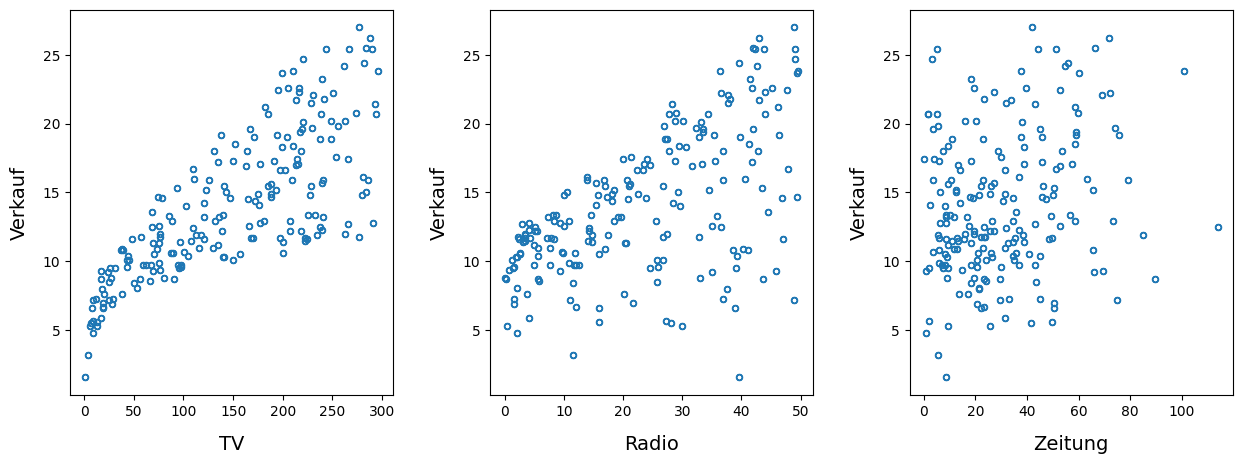

In [19]:
# Figurobjekt erstellen
fig = plt.figure(figsize=(15,5))

# Achse für das Streudiagramm TV - Verkauf
ax1 = fig.add_subplot(1,3,1)
werbung.plot.scatter(x = "TV", y = "Verkauf", ax = ax1, marker="$\u25EF$")
ax1.set_xlabel("TV",size=14,labelpad=12)
ax1.set_ylabel("Verkauf",size=14,labelpad=10)

# Achse für das Streudiagramm Radio - Verkauf
ax2 = fig.add_subplot(1,3,2)
werbung.plot.scatter(x = "Radio", y = "Verkauf", ax = ax2, marker="$\u25EF$")
ax2.set_xlabel("Radio",size=14,labelpad=12)
ax2.set_ylabel("Verkauf",size=14,labelpad=10)

# Achse für das Streudiagramm Zeitung - Verkauf
ax3 = fig.add_subplot(1,3,3)
werbung.plot.scatter(x = "Zeitung", y = "Verkauf", ax = ax3, marker="$\u25EF$")
ax3.set_xlabel("Zeitung",size=14,labelpad=12)
ax3.set_ylabel("Verkauf",size=14,labelpad=10)

plt.subplots_adjust(wspace=0.3)

plt.show()

Wir schätzen nun die vier **Paramter des multiplen linearen Modells** $$\texttt{Verkauf} = \pmb{a_1}\cdot\texttt{TV} + \pmb{a_2}\cdot\texttt{Radio} + \pmb{a_3}\cdot\texttt{Zeitung} + \pmb{b}$$

In [20]:
from scipy.optimize import minimize

def model(TV, Radio, Zeitung, a_TV=1, a_Radio=1, a_Zeitung=1, b=0):
    return a_TV*TV + a_Radio*Radio + a_Zeitung*Zeitung + b

def RSS(parameter):
    residuen = werbung["Verkauf"] - model(werbung["TV"],
                                          werbung["Radio"],
                                          werbung["Zeitung"],
                                          a_TV = parameter[0],
                                          a_Radio = parameter[1],
                                          a_Zeitung = parameter[2],
                                          b = parameter[3])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(4)+0.1)
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 556.825262903427
        x: [ 4.576e-02  1.885e-01 -1.038e-03  2.939e+00]
      nit: 8
      jac: [-7.629e-06 -7.629e-06 -7.629e-06 -7.629e-06]
 hess_inv: [[ 2.086e-07 -5.858e-07 -3.577e-07  1.111e-06]
            [-5.858e-07  1.128e-05 -4.309e-06 -1.708e-05]
            [-3.577e-07 -4.309e-06  5.404e-06  3.927e-06]
            [ 1.111e-06 -1.708e-05  3.927e-06  2.856e-05]]
     nfev: 80
     njev: 16

Mit diesen Paramtern können wir die ***Prädiktorfunktion für die Zeilgrösse*** **Verkauf** $$\begin{align*}\texttt{Verkauf} &\;\;=\;\; \texttt{predict}(\texttt{TV},\texttt{Radio},\texttt{Zeitung}) \\ &\;\;=\;\;0.04576\cdot\texttt{TV} + 0.1885\cdot\texttt{Radio} - 0.001038\cdot\texttt{Zeitung} + 2.939\rule{0cm}{1cm}\end{align*}$$
implementieren:

In [21]:
def predict(TV,Radio,Zeitung):
    return model(TV,Radio,Zeitung,
                 a_TV = fit.x[0],
                 a_Radio = fit.x[1],
                 a_Zeitung = fit.x[2],
                 b = fit.x[3])

Den **Standardfehler der Residuen** (RSE) finden wir mit der **Summe der Residuenquadrate** (RSS), die als Minimalwert in $\texttt{fit.fun}$ gespeichert ist:  

In [22]:
# Anzahl Prädiktoren
m = 3 

# Residual standard Error 
RSE = np.sqrt(fit.fun / (werbung.shape[0] - (m + 1)))

print(RSE)

1.6855103734166206


Das **Bestimmtheitsmass** $\,\pmb{R^2}\,$ für das Modell finden wir aus dem Quotienten der **mittleren Quadratischen Abweichungen** (MQD) **des Verkaufs** im Modell und in den Daten:

In [23]:
R_squared = (predict(werbung["TV"],werbung["Radio"],werbung["Zeitung"]).var() / 
             werbung["Verkauf"].var())
print(R_squared)

0.8972098546301099


Das Bestimmtheitsmass sagt uns, dass **ungefähr 90% der mittleren quadratsichen Abweichung** mit dem multiplen linearen Modell erklärt wird.

Ob die ***beobachteten Regressionsparameter*** allenfalls rein zufällig entstanden sind, testen wir für jeden Prädiktor mit der Zeilvariablen separat: 

- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_1}$ des Prädiktors **TV** ist $\quad \pmb{H_0:\; a_1 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_1 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_2}$ des Prädiktors **Radio** ist $\quad \pmb{H_0:\; a_2 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_2 \neq 0}$
- Die **Nullhypothese** für das **Gewicht** $\,\pmb{a_3}$ des Prädiktors **Zeitung** ist $\quad \pmb{H_0:\; a_3 = 0}$ <br>
mit der **Alternativhypothese** $\quad \pmb{H_1:\; a_3 \neq 0}$

Mit einem **Permutationstest** können die $\pmb{p}$**-Werte** berechnen und diese Hypothesen testen:

In [24]:
import seaborn as sns
import numpy as np

''' Permutationstest '''

# Anzahl Permutationen
n_permutations = 1000

# Parameter bei den Permutationen
parameterTV_permuted = []
parameterRadio_permuted = []
parameterZeitung_permuted = []

for _ in range(n_permutations):
    # Werte des Merkmals Verkauf zufällig permutieren
    Verkauf_permuted = np.random.permutation(werbung["Verkauf"])

    # die zu minimierende Funktion für die neuen Daten
    def RSS(parameter):
        residuen = Verkauf_permuted - model(werbung["TV"],
                                          werbung["Radio"],
                                          werbung["Zeitung"],
                                          a_TV = parameter[0],
                                          a_Radio = parameter[1],
                                          a_Zeitung = parameter[2],
                                          b = parameter[3])
        return (residuen**2).sum()

    # Lösung des Minimierungsproblems
    fit_permuted = minimize(RSS, x0=np.zeros(4)+0.1)

    # Geschätzte Parameter bei den permutierten Daten
    parameterTV_permuted.append(fit_permuted.x[0])
    parameterRadio_permuted.append(fit_permuted.x[1])
    parameterZeitung_permuted.append(fit_permuted.x[2])

# p-Wert berechnen (zweiseitig)
parameterTV_permuted = np.array(parameterTV_permuted)
p_value_TV = 100*np.mean(np.abs(parameterTV_permuted) >= np.abs(fit.x[0]))

parameterRadio_permuted = np.array(parameterRadio_permuted)
p_value_Radio = 100*np.mean(np.abs(parameterRadio_permuted) >= np.abs(fit.x[1]))

parameterZeitung_permuted = np.array(parameterZeitung_permuted)
p_value_Zeitung = 100*np.mean(np.abs(parameterZeitung_permuted) >= np.abs(fit.x[2]))

print(f"Beobachteter Parameter für TV: {fit.x[0]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_TV:}")
print(f"Beobachteter Parameter für Radio: {fit.x[1]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Radio:}")
print(f"Beobachteter Parameter für Zeitung: {fit.x[2]:.4f}")
print(f"Resampling-basierter p-Wert: {p_value_Zeitung:}")


Beobachteter Parameter für TV: 0.0458
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Radio: 0.1885
Resampling-basierter p-Wert: 0.0
Beobachteter Parameter für Zeitung: -0.0010
Resampling-basierter p-Wert: 95.6


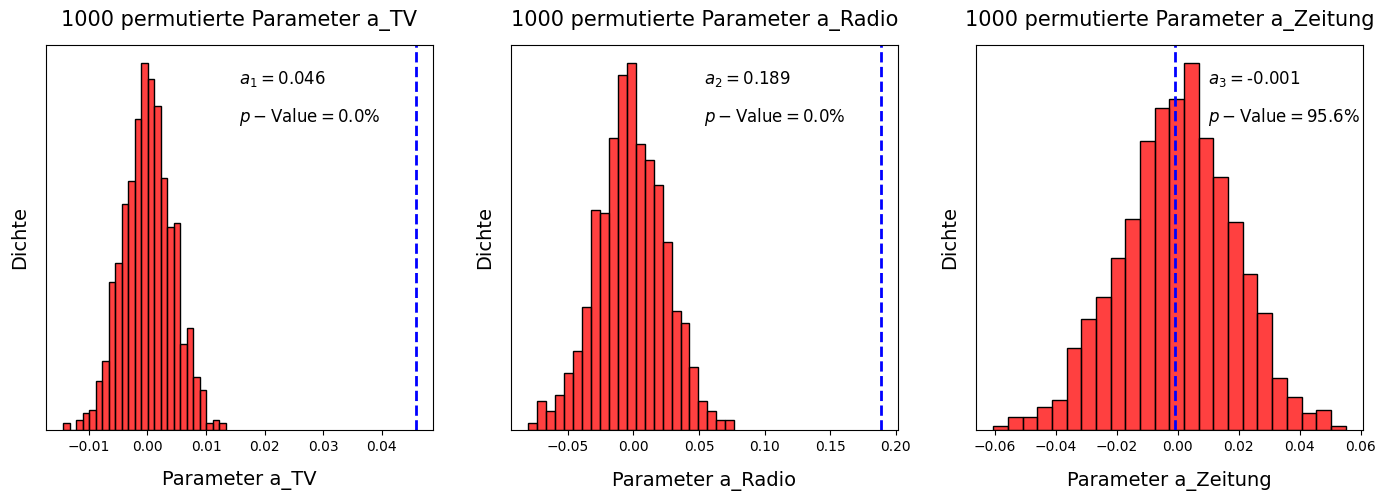

In [25]:
''' Visualisierung des Testergebnisses '''

# Figurobjekt erstellen
fig = plt.figure(figsize=(17,5))

# Koordinatensystem erstellen
ax1 = fig.add_subplot(1,3,1)

# Dichtediagramm für die Parameter a_TV aus den Permutationen
sns.histplot(parameterTV_permuted,stat="density",ax=ax1,color="red")

# vertikale Linie beim beobachteten Parameter a_TV
ax1.axvline(fit.x[0],color="blue",lw=2,linestyle="dashed")
ax1.text(0.5,0.9,r"$a_1=$"+"{m:1.3f}".format(m=fit.x[0]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
ax1.text(0.5,0.8,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value_TV),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
ax1.set_title("1000 permutierte Parameter a_TV", fontsize=15,pad=14)
ax1.set_xlabel("Parameter a_TV",size=14,labelpad=12)
ax1.set_ylabel("Dichte",size=14,labelpad=12)
ax1.set_yticks([])

# Koordinatensystem erstellen
ax2 = fig.add_subplot(1,3,2)

# Dichtediagramm für die Parameter a_Radio aus den Permutationen
sns.histplot(parameterRadio_permuted,stat="density",ax=ax2,color="red")

# vertikale Linie beim beobachteten Parameter a_Radio
ax2.axvline(fit.x[1],color="blue",lw=2,linestyle="dashed")
ax2.text(0.5,0.9,r"$a_2=$"+"{m:1.3f}".format(m=fit.x[1]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
ax2.text(0.5,0.8,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value_Radio),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
ax2.set_title("1000 permutierte Parameter a_Radio", fontsize=15,pad=14)
ax2.set_xlabel("Parameter a_Radio",size=14,labelpad=12)
ax2.set_ylabel("Dichte",size=14,labelpad=12)
ax2.set_yticks([])

# Koordinatensystem erstellen
ax3 = fig.add_subplot(1,3,3)

# Dichtediagramm für die Parameter a_Zeitung aus den Permutationen
sns.histplot(parameterZeitung_permuted,stat="density",ax=ax3,color="red")

# vertikale Linie beim beobachteten Parameter a_Zeitung
ax3.axvline(fit.x[2],color="blue",lw=2,linestyle="dashed")
ax3.text(0.6,0.9,r"$a_3=$"+"{m:1.3f}".format(m=fit.x[2]),
                   fontsize=12,transform=plt.gca().transAxes)

# p-Wert
ax3.text(0.6,0.8,r"$p-$"+"Value"+r"$ = $"+"{p:1.1f}%".format(p=p_value_Zeitung),
                   fontsize=12,transform=plt.gca().transAxes)

# Achsen beschriften
ax3.set_title("1000 permutierte Parameter a_Zeitung", fontsize=15,pad=14)
ax3.set_xlabel("Parameter a_Zeitung",size=14,labelpad=12)
ax3.set_ylabel("Dichte",size=14,labelpad=12)
ax3.set_yticks([])

# Figur zeigen
plt.show()

Mit den p-Werten können wir die Hypothesen entscheiden:
- Der beobachtete Parameter $\,\pmb{\hat{a}_1}\,$ beim Prädiktor **TV** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_2}\,$ beim Prädiktor **Radio** kann **nicht durch Zufall erklärt werden**, der p-Wert ist 0%. </br>
Wir **verwerfen die Nullhypothese** und **nehmen die Alternativhypothese an**.
- Der beobachtete Parameter $\,\pmb{\hat{a}_3}\,$ beim Prädiktor **Zeitung** kann **durch Zufall erklärt werden**, der p-Wert ist viel grösser als 5%. </br>
Wir **verwerfen die Nullhypothese nicht**.

Wir können auch untersuchen, ob es **Korrelationen zwischen den Prädiktoren** gibt:

In [26]:
# Korrelationskoeffizienten berechnen
werbung[["TV","Radio","Zeitung"]].corr() 

,TV,Radio,Zeitung
TV,1.000000,0.054809,0.056648
Radio,0.054809,1.000000,0.354104
Zeitung,0.056648,0.354104,1.000000


In der Tat sehen wir eine **schwache positive Korrelation** zwischen dem Prädiktor **Radio** und **Zeitung**, der Korrelationskoeffizient ist $\pmb{r=0.354}$. Das heisst: 
- Je mehr in Radiowerbung investiert wird, desto mehr wird in Zeitungswerbung investiert.

Den Prädiktor **Zeitung** können wir weglassen und das multiple lineare Modell neu nur mit den zwei Prädiktoren **TV** und **Radio** schätzen:

In [27]:
def model(TV,Radio,a_TV = 1,a_Radio = 1,b = 0):
    return a_TV*TV + a_Radio*Radio + b

def RSS(parameter):
    residuen = werbung["Verkauf"] - model(werbung["TV"],
                                          werbung["Radio"],
                                          a_TV = parameter[0],
                                          a_Radio = parameter[1],
                                          b = parameter[2])
    return (residuen**2).sum()

fit = minimize(RSS, x0=np.zeros(3)+0.2)
fit

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 556.9139800689032
        x: [ 4.575e-02  1.880e-01  2.921e+00]
      nit: 4
      jac: [ 0.000e+00 -7.629e-06  7.629e-06]
 hess_inv: [[ 3.419e-07 -1.084e-07 -4.775e-05]
            [-1.084e-07  1.143e-05 -2.500e-04]
            [-4.775e-05 -2.500e-04  1.534e-02]]
     nfev: 28
     njev: 7

Mit diesen neuen Paramtern können wir die ***Prädiktorfunktion für die Zeilgrösse*** **Verkauf** $$\begin{align*}\texttt{Verkauf} &\;\;=\;\; \texttt{predict}(\texttt{TV},\texttt{Radio}) \\ &\;\;=\;\;0.04575\cdot\texttt{TV} + 0.188\cdot\texttt{Radio} + 2.921\rule{0cm}{1cm}\end{align*}$$
nur mit zwei Prädiktoren implementieren:

In [28]:
def predict2(TV,Radio):
    return model(TV,Radio, a_TV = fit.x[0], a_Radio = fit.x[1], b = fit.x[2])

Nun vergleichen wir den **Standardfehler der Residuen** (RSE) und das **Bestimmtheitsmass** $\,\pmb{R^2}\,$ der zwei Modelle:

In [29]:
# Anzahl Prädiktoren
m = 2 

# Residual standard Error mit Prädiktoren 
RSE2 = np.sqrt(fit.fun / (werbung.shape[0] - (m+1))) 

# Bestimmtheitsmass mit zwei Prädiktoren
R_squared2 = (predict2(werbung["TV"],werbung["Radio"]).var() / 
              werbung["Verkauf"].var())

# Vergleich
print("-- Multiples lineares Modell mit Prädiktoren TV und Radio --")
print("    R_squared:", round(R_squared2,5)) 
print("          RSE:", round(RSE2,5),end="\n\n") 

print("-- Multiples lineares Modell mit Prädiktoren TV, Radio und Zeitung --")
print("    R_squared:", round(R_squared,5))
print("          RSE:", round(RSE,5)) 

-- Multiples lineares Modell mit Prädiktoren TV und Radio --
    R_squared: 0.89719
          RSE: 1.68136

-- Multiples lineares Modell mit Prädiktoren TV, Radio und Zeitung --
    R_squared: 0.89721
          RSE: 1.68551


Das Modell mit nur den Prädiktoren **TV** und **Radio** hat
- einen geringfügig kleineren $\,\pmb{R^2}\,$ Wert.
- der **Standardfehler der Residuen** (RSE) ist sogar kleiner.

<span style="color:rgb(160,0,86)">**Merksatz:**</span> ***Allgemein wird das Bestimmtheitsmass grösser oder bleigt gleich, wenn wir mehr Prädiktoren im Modell berücksichtigen.***

### <span style="color:rgb(160,0,86)">Was ist eine Kreuzvalidierung?</span>

Die bis anhin betrachteten Regressionsgrössen zur **Beurteilung des Modells** sind allesamt **stichprobenintern** (in-Sample). Sie werden auf Grundlage derselben Daten ermittelt, die zur Anpassung des Modells verwendet werden. 

Es ist sinnvoll **einen Teil** der ursprünglichen Daten **beiseitezulegen**, sie nicht zur Anpassung des Modells zu verwenden und **das Modell** dann auf diesen zurückgelegten Daten **anzuwenden**, um zu sehen, wie gut es abschneidet (out-of-Sample).

Wenn wir eine **Hold-out-Stichprobe für das Testen des Modells** verwenden, sind wir jedoch einer **gewissen Unsicherheit** ausgesetzt, die sich aus der Variabilität dieser kleinen Stichprobe ergibt. Es stellt sich die Frage: 
- Wie unterschiedlich würde das Modell abschneiden, wenn wir **eine andere Hold-out-Stichprobe** für das Testen brauchen.

Das folgende Verfahren dehnt die Idee einer Hold-out-Stichprobe für das Testen des Modells auf **mehrere aufeinanderfolgende Ziehungen von Hold-out-Stichproben** aus:

**Kreuzvalidierungs-Algorithmus**

<tt> <strong>1. Schritt:</strong> Legen Sie $1/k$ der Daten als **Hold-out-Stichprobe** beiseite. </br>
<strong>2. Schritt:</strong> Trainieren Sie das Modell mit den übrigen Daten. </br>
<strong>3. Schritt:</strong> Wenden Sie das Modell auf die **Hold-out-Stichprobe** an und erfassen Sie ein Gütemass zur Bewertung des Modells. </br>
<strong>4. Schritt:</strong> Wiederholen Sie die Schritte 1 bis 3, bis alle Daten jeweils einmal in der **Hold-out-Stichprobe** verwendet wurden. </br>
<strong>5. Schritt:</strong> Bilden Sie den Mittelwert der ermittelten Gütemasse.
</tt>

Oft wird der **Root-Mean-Square-Error** $$\textbf{RMSE} = \sqrt{\frac{r_1^2+r_2^2+r_3^2+\ldots+r_{\lfloor n/k\rfloor}^2}{\lfloor n/k\rfloor}} $$ als **Gütemass für den Erfolg** verwendet.

Eine einfache **Umsetzung der Kreuzvalidierung** unterteil zu Beginn die zufällig **gemischten Daten** in ungefähr $\,\pmb{k}\,$ **gleich grosse Teile** und verwendet dann all diese Teile je **genau einmal als Hold-out-Stichprobe**.

- Mit der Methode <tt><strong>sample( )</strong></tt> können wir eine Zufallsstichprobe aus den Zeilen eines DataFrames zeihen. Wenn wir den Parameter <tt><strong>frac=1</strong></tt> setzen, werden 100% der Zeilen gezogen, aber in zufälliger Reihenfolge. Damit erstellen wir eine **zufällige Permuation der Zeilen** des DataFrames.

In [30]:
# zufällige Reihenfolge
werbung_shuffled = werbung.sample(frac=1)

# in 4 ungefähr gleich große Teile aufteilen
dfs = np.array_split(werbung_shuffled, 4)

print([len(dfs[i]) for i in range(4)])

[50, 50, 50, 50]


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


Weil wir bei der Kreuzvalidierung das **Modell mehrfach berechnen**, definieren wir die folgende Funktion <tt><strong>fit_and_evaluate()</strong></tt>

In [31]:
def fit_and_evaluate(werbung_train, werbung_test):
    """
    Trainiert ein lineares Modell auf werbung_train und 
    berechnet RMSE auf werbung_test.
        
    Returns: RMSE (float): Root Mean Squared Error auf den Testdaten
    """
    
    # Modell
    def model(TV, Radio, a_TV=1, a_Radio=1, b=0):
        return a_TV * TV + a_Radio * Radio + b

    # RSS-Funktion
    def RSS(parameter):
        residuen = werbung_train["Verkauf"] - model(werbung_train["TV"],
                                                    werbung_train["Radio"],
                                                    a_TV = parameter[0],
                                                    a_Radio = parameter[1],
                                                    b = parameter[2])
        return (residuen**2).sum()

    # Parameter schätzen
    fit = minimize(RSS, x0=np.zeros(3) + 0.2)

    # Vorhersagefunktion
    def predict(TV, Radio):
        return model(TV,Radio,a_TV=fit.x[0],a_Radio=fit.x[1],b=fit.x[2])

    # RMSE auf Testdaten
    RMSE = np.sqrt(((werbung_test["Verkauf"] - 
            predict(werbung_test["TV"], werbung_test["Radio"]))**2).mean())

    return RMSE

Nun können wir die **Kreuzvalidierung mit den vier Hold-out-Stichporben** durchführen:

In [32]:
RMSEs = []

for i in range(len(dfs)):
    # Testset ist das i-te DataFrame
    werbung_test = dfs[i]
    
    # Trainingsset: alle anderen DataFrames zusammenfügen
    werbung_train = pd.concat([dfs[j] for j in range(len(dfs)) if j != i])
    
    # RMSE berechnen
    RMSE = fit_and_evaluate(werbung_train, werbung_test)
    
    # Ergebnisse speichern
    RMSEs.append({'test_df': i+1, 'RMSE': RMSE})

# Übersicht der RMSEs
for r in RMSEs:
    print(f"Test-Set df{r['test_df']}: RMSE = {r['RMSE']:.4f}")

# Durchschnitt der RMSEs
print("Mittelwert der RMSE-Werte:", np.array([r['RMSE'] for r in RMSEs]).mean())

Test-Set df1: RMSE = 2.0815
Test-Set df2: RMSE = 1.7099
Test-Set df3: RMSE = 1.4988
Test-Set df4: RMSE = 1.5253
Mittelwert der RMSE-Werte: 1.7038553058220725


### <span style="color:rgb(160,0,86)">Wie können nicht metrische Merkmale berücksichtigt werden?</span>

- Die Werte eines **ordinalen Merkmales** werden in vernünftige Zahlen übersetzt.
- Die Werte eines **nominalen Merkmals** werden mit **Dummy-Variablen (0/1-Variablen)** abgebildet. Für $k$ Werte braucht es $k-1$ Dummy-Variablen. Ein Wert wird als **Baseline** bezeichnet.

Zum Beispiel können wir das Merkmal **Geschlecht G** mit den zwei Werten ***Frau*** und ***Mann*** mit einer **Dummy-Variable** abbilden:
$$G_{\texttt{Mann}}(x) = \begin{cases}\;1&: \;\text{ wenn } x = \texttt{"Mann"}\\ \;0&: \;\text{ wenn } x = \texttt{"Frau"}\rule{0cm}{1cm}\end{cases}$$
Mit dieser Codierung haben wir den Wert ***Frau*** als **Baseline** gewählt.

Das Merkmal **Blutgruppe BG** mit den drei Werte ***A***, ***B*** und ***AB*** können wir mit zwei Dummy-Variablen abbilden:
$$BG_{\texttt{A}}(x) = \begin{cases}\;1&: \;\text{ wenn } x = \texttt{"A"}\\ \;0&: \;\text{ sonst }\rule{0cm}{1cm}\end{cases}\quad \text{ und }\quad BG_{\texttt{B}}(x) = \begin{cases}\;1&: \;\text{ wenn } x = \texttt{"B"}\\ \;0&: \;\text{ sonst }\rule{0cm}{1cm}\end{cases}$$ Mit dieser Codierung haben wir den Wert ***AB*** als **Baseline** gewählt. In einem multiplen linearen Modell werden nun statt dem Prädiktor **BG** die beiden Dummy-Variablen integriert: $$a_1\cdot BG_{\texttt{A}} + a_2\cdot BG_{\texttt{B}}$$
- Das **Gewicht** $\pmb{a_1}$ beschreibt, welchen Einfluss die Blutgruppe **A** hat.
- Das **Gewicht** $\pmb{a_2}$ beschreibt, welchen Einfluss die Blutgruppe **B** hat.

Auch wenn die Blutgruppe **AB** keine eigene Dummy-Variable hat, ist ihr **Einfluss** trotzdem im Modell enthalten – nur **indirekt über den Parameter** $\,\pmb{b}\,$.

In [33]:
immo = pd.read_csv("/Users/muellefa/repos/ASTAT/SW12/Daten/house_sales.csv",sep="\t")
immo.head(10)

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,Bathrooms,Bedrooms,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,3.00,6,7,1991,0,0,70000,229000,98002,False
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,3.75,4,10,2005,0,0,203000,590000,98166,True
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1.75,4,8,1947,0,0,183000,275000,98166,False
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,3.75,5,7,1966,0,0,104000,229000,98168,False
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1.75,4,7,1948,0,0,104000,205000,98168,False
6,2009-03-30,349900,3600090,Townhouse,2009-03-01,369800,0.849724,411781.0,1,1012,...,1.50,2,8,2008,0,0,170000,207000,98144,True
7,2013-08-28,327500,3800004,Single Family,2013-08-01,374300,0.860064,380785.0,1,34465,...,1.50,3,8,1961,0,0,165000,227000,98178,False
8,2007-05-24,347000,3800009,Single Family,2007-05-01,432100,0.992877,349489.0,1,14659,...,1.75,4,7,1963,0,0,115000,154000,98178,False
9,2006-09-22,220400,6600055,Single Family,2006-09-01,414800,0.953125,231239.0,1,5324,...,1.00,2,6,1930,0,3,90000,75000,98032,False
10,2006-08-22,437500,7200080,Multiplex,2006-08-01,411100,0.944623,463148.0,2,10585,...,2.00,4,6,1924,0,0,124000,116000,98055,False


In diesem Datensatz zum Beispiel das Merkmal **PropertyType** nominal und die die drei Werte <tt><strong>Multiplex</strong></tt>, <tt><strong>Singel Family</strong></tt> und <tt><strong>Townhouse</strong></tt>.

Mit der Funnktion <tt><strong>get_dummies( )</strong></tt> können wir die **Dummy-Variablen automatisch erstellen**:

In [34]:
pd.get_dummies(immo["PropertyType"]).head()

,Multiplex,Single Family,Townhouse
1,True,False,False
2,False,True,False
3,False,True,False
4,False,True,False
5,False,True,False


MIt dem **Parameter** <tt><strong>drop_first=True</strong></tt> können wir die **Baseline setzen**:

In [35]:
# Erster Wert ist die Basis
pd.get_dummies(immo["PropertyType"],drop_first=True).head()

,Single Family,Townhouse
1,False,False
2,True,False
3,True,False
4,True,False
5,True,False


MIt dem **Parameter** <tt><strong>dtype=int</strong></tt> können wir Dummy-Variable auf die **0/1-Codierung** umstellen:

In [36]:
# Null-Eins-Codierung
pd.get_dummies(immo["PropertyType"],drop_first=True,dtype=int).head()

,Single Family,Townhouse
1,0,0
2,1,0
3,1,0
4,1,0
5,1,0


Damit können wir aus dem Datensatz **immo** zum Beispiel **die Merkmale** $$\tiny\texttt{"SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade","PropertyType"}$$ **ausschneiden** und sie mit dem Einführen von Dummy-Variablen **für eine multiple lineare Regression vorbereiten**:

In [37]:
teilmenge = ["SqFtTotLiving","SqFtLot","Bathrooms","Bedrooms","BldgGrade","PropertyType"]

df = pd.get_dummies(immo[teilmenge],drop_first=True,dtype=int)
df.head()

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,PropertyType_Single Family,PropertyType_Townhouse
1,2400,9373,3.00,6,7,0,0
2,3764,20156,3.75,4,10,1,0
3,2060,26036,1.75,4,8,1,0
4,3200,8618,3.75,5,7,1,0
5,1720,8620,1.75,4,7,1,0


In [38]:
predictors = df.columns
predictors

Index(['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade',
       'PropertyType_Single Family', 'PropertyType_Townhouse'],
      dtype='object')

### <span style="color:rgb(160,0,86)">Wie finden wir ein gutes Modell?</span>

Oft stehen sehr viele Merkmale als Prädiktoren für eine Zielvariable zur Verfügung. 
- **Möglichst viele Prädiktoren** zum Modell hinzuzufügen, **bedeutet** jedoch **nicht unbedingt**, dass wir ein **besseres Modell** erhalten.

Wir sollten uns besser bei der Wahl des Modells am **Prinzip der Sparsamkeit** orientieren. 

- <span style="color:rgb(160,0,86)">**Sofern Aspekte von Modellen gleich sind, sollte das einfachere Modell vorgezogen werden!**</span>

Eine Möglichkeit besteht darin, dass wir mit dem einfachsten Modell beginnen  und schrittweise den Prädiktor hinzufügen, der das Modell am besten erweitert (**Vorwärtsselektion**). Wenn die Verbesserung nicht mehr deutlich erkennbar ist, stoppen wir die Erweiterung des Modells:

**Vorwärtsselektions-Algorithmus**

<tt> <strong>1. Schritt:</strong> Wähle das einfache lineare Modell mit dem kleinsten **RSS**-Wert. </br>
<strong>2. Schritt:</strong> Berechne das **Informationskriterium nach Akaike** (*Akaike's Information Criteria*) $$\textbf{AIC} = \underbrace{\textcolor{white}{/}2\cdot \textbf{Anzahl Parameter im Modell\textcolor{white}{/}}}_{\text{Bestrafung: wird grösser}} + \underbrace{\textcolor{white}{/}\pmb{n}\cdot \log(\,\textbf{RSS}/\pmb{n}\,)\textcolor{white}{/}}_{\text{Belohnung: wird kleiner}}$$ wobei $\pmb{n}$ die Anzahl der Daten in der Stichprobe ist. </br>
<strong>3. Schritt:</strong> Ergänze das aktuelle Modell mit einem Prädiktor, so dass der kleinste **RSS**-Wert entsteht. </br>
<strong>4. Schritt:</strong> Wiederhole die Schritte 2 bis 3, bis der **AIC**-Wert nicht mehr abnimmt.
</tt>
 

In [39]:
def model(A_1,a_1 = 1,b = 0):
    return a_1*A_1 + b

def RSS(parameter):
    residuen = immo["AdjSalePrice"] - model(df[predictors[0]],
                                            a_1 = parameter[0],
                                            b = parameter[1])
    return (residuen**2).sum()

fit = minimize(RSS, x0=[2.938e+02,-4.623e+04])
RSS_1 = fit.fun
AIC_1 = 2 * 2 + df.shape[0]*np.log(RSS_1 / df.shape[0])
fit

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 1741356587225015.5
        x: [ 2.938e+02 -4.623e+04]
      nit: 1
      jac: [ 1.678e+07  0.000e+00]
 hess_inv: [[ 6.250e-06 -2.500e-03]
            [-2.500e-03  1.000e+00]]
     nfev: 136
     njev: 42

In [40]:
print(RSS_1)
print(AIC_1)

1741356587225015.5
568628.5518345735


### <span style="color:rgb(160,0,86)">Aufgabe 1</span>

Vervollständigen Sie diese **Vorwärtsselektion**. 

In [41]:
# To do!

### <span style="color:rgb(160,0,86)">Aufgabe 2</span>

Machen Sie eine multiple lineare Korrelationsananalyse mit dem Datensatz *Credit.csv* für die Zeilvariable
- die **Kreditwürdigkeit** (*Rating*).
- die **Kontostand bzw. Schuldenstand** (*Balance*) 

In [42]:
# To do!

![HSLU](Bilder/LogoHSLU.png)